<h3 style="color: #e0e0ff; font-style: italic;">📝 Multimodal Inverse Attention Network (MIAN) for Multimodal Fake News Detection</h3>

---

**Benchmark Alignment Note:** This notebook is structured to ensure a **100% fair and controlled comparison** with **HMCAN** on the **M4FC Dataset**.
- **Identical Data Split:** Stratified 85/15 train-val/test split (`random_state=42`).
- **Identical Backbones:** Text → `xlm-roberta-base` (768-dim), Vision → `openai/clip-vit-base-patch16` (768-dim patch sequence).
- **Identical Loss & Optimization:** Inverse class frequency weighted `CrossEntropyLoss`, `AdamW` (`lr=1e-4`), `CosineAnnealingLR`, batch size 16.
- **Standardized Dataset:** Uses unified `M4FCDataset` from `src/data_pipeline.py`.

---

**🔧 How MIAN Works**

**Step 1: Extract Base Representations**
- Text → XLM-RoBERTa-base → 768-dim token sequence features (Frozen)
- Image → CLIP ViT-B/16 → 768-dim patch sequence features (197 patches, Frozen)

**Step 2: Intra-modal Feature Refinement (HLM)**
- Text sequence → 1D Conv + Self-Attention → 256-dim refined text sequence
- Image sequence → 1D Conv + Self-Attention → 256-dim refined vision sequence

**Step 3: Cross-Modal Co-Attention & Inverse Attention**
- Compute similarity score matrix $S = \frac{Q_t K_i^T}{\sqrt{d}}$
- Softmax over $S$ → Co-Attention weights (extract matching features)
- Softmax over $1.0 - S$ → Inverse Attention weights (extract discrepant features)

**Step 4: Metadata Fusion & Classification**
- Concatenate matching text, matching image, discrepant text, discrepant image, and encoded metadata (1088-dim total)
- Pass through BatchNorm + Dropout (0.4) + Dense classifier to predict Fake (1) vs Real (0)


**Imports and Setup**

In [1]:
# Core Imports
import os
import sys
import time
import json
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW

# Transformers
from transformers import XLMRobertaModel, XLMRobertaTokenizer, CLIPVisionModel, CLIPProcessor

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, accuracy_score, precision_recall_fscore_support, roc_curve, auc
)

import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, "../../src")
from data_pipeline import M4FCDataset, M4FCDataPipeline
from model_registry import update_registry

c:\Users\SAFAE ERAJI\Desktop\M2\Stage PFE\multimodal_fake_news_detection\venv_ai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Device: {device}")

🚀 Device: cuda


**Data Preparation**

In [3]:
print("📂 Loading CSV metadata...")
df = pd.read_csv('../../data/M4FC.csv')
print(f"✅ Metadata loaded: {len(df)} rows")

tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')
processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch16')
print("✅ Tokenizer & Processor loaded")

📂 Loading CSV metadata...
✅ Metadata loaded: 4948 rows


✅ Tokenizer & Processor loaded


In [4]:
indices = np.arange(len(df))
idx_temp, idx_test = train_test_split(
    indices,
    test_size=0.15,
    random_state=42,
    stratify=df['target'].values
)
idx_train, idx_val = train_test_split(
    idx_temp,
    test_size=0.15 / 0.85,
    random_state=42,
    stratify=df['target'].values[idx_temp]
)

train_df = df.iloc[idx_train].reset_index(drop=True)
val_df = df.iloc[idx_val].reset_index(drop=True)
test_df = df.iloc[idx_test].reset_index(drop=True)

train_dataset = M4FCDataset(train_df, tokenizer, processor)
val_dataset = M4FCDataset(val_df, tokenizer, processor)
test_dataset = M4FCDataset(test_df, tokenizer, processor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"✓ Dataset split: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

✓ Dataset split: Train=3462, Val=743, Test=743


**Backbone Feature Encoders**

In [5]:
print("=" * 50)
print("📥 STEP 1/2: Loading XLM-RoBERTa...")
print("=" * 50)
text_encoder = XLMRobertaModel.from_pretrained('xlm-roberta-base', use_safetensors=True)
for param in text_encoder.parameters():
    param.requires_grad = False
print("✅ XLM-RoBERTa loaded & frozen")

print("=" * 50)
print("📥 STEP 2/2: Loading CLIP ViT-B/16...")
print("=" * 50)
image_encoder = CLIPVisionModel.from_pretrained('openai/clip-vit-base-patch16', use_safetensors=True)
for param in image_encoder.parameters():
    param.requires_grad = False
print("✅ CLIP ViT-B/16 loaded & frozen")

📥 STEP 1/2: Loading XLM-RoBERTa...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3262.05it/s]
[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ XLM-RoBERTa loaded & frozen
📥 STEP 2/2: Loading CLIP ViT-B/16...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3372.47it/s]
[transformers] CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.embeddings.position_embedding.weight      

✅ CLIP ViT-B/16 loaded & frozen


**MIAN Model Architecture**

In [6]:
class HierarchicalLearningModule(nn.Module):
    """Intra-modal feature refinement via 1D Conv + Multi-Head Self-Attention"""
    def __init__(self, input_dim=768, hidden_dim=256):
        super().__init__()
        self.conv1d = nn.Conv1d(input_dim, hidden_dim, kernel_size=3, padding=1)
        self.self_attn = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=4, batch_first=True)
        self.norm = nn.LayerNorm(hidden_dim)
        
    def forward(self, x):
        h = x.permute(0, 2, 1)
        h1 = F.relu(self.conv1d(h)).permute(0, 2, 1)
        attn_out, _ = self.self_attn(h1, h1, h1)
        out = self.norm(h1 + attn_out)
        return out

class CoAttention(nn.Module):
    """Cross-Modal Co-Attention + Inverse Attention to extract matching & discrepant features"""
    def __init__(self, text_dim=256, image_dim=256, hidden_dim=256):
        super().__init__()
        self.text_proj = nn.Linear(text_dim, hidden_dim)
        self.image_proj = nn.Linear(image_dim, hidden_dim)
        self.w_t = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.w_i = nn.Linear(hidden_dim, hidden_dim, bias=False)
        
    def forward(self, text_feats, image_feats):
        t_proj = self.text_proj(text_feats)
        i_proj = self.image_proj(image_feats)
        
        t_proj_w = self.w_t(t_proj)
        i_proj_w = self.w_i(i_proj)
        
        scores = torch.matmul(t_proj_w, i_proj_w.transpose(1, 2)) / np.sqrt(t_proj.size(-1))
        
        attn_t2i = F.softmax(scores, dim=-1)
        attn_i2t = F.softmax(scores.transpose(1, 2), dim=-1)
        
        fused_t = torch.matmul(attn_t2i, i_proj)
        fused_i = torch.matmul(attn_i2t, t_proj)
        
        attn_t2i_inv = F.softmax(1.0 - attn_t2i, dim=-1)
        attn_i2t_inv = F.softmax(1.0 - attn_i2t, dim=-1)
        
        inv_fused_t = torch.matmul(attn_t2i_inv, i_proj)
        inv_fused_i = torch.matmul(attn_i2t_inv, t_proj)
        
        text_rep = torch.cat([fused_t, inv_fused_t], dim=-1).mean(dim=1)
        image_rep = torch.cat([fused_i, inv_fused_i], dim=-1).mean(dim=1)
        return text_rep, image_rep


class MIANModel(nn.Module):
    def __init__(self, text_encoder, image_encoder, num_classes=2, use_metadata=True):
        super().__init__()
        self.use_metadata = use_metadata
        self.text_encoder = text_encoder
        self.image_encoder = image_encoder
        
        self.text_hlm = HierarchicalLearningModule(input_dim=768, hidden_dim=256)
        self.image_hlm = HierarchicalLearningModule(input_dim=768, hidden_dim=256)
        self.co_attention = CoAttention(text_dim=256, image_dim=256, hidden_dim=256)
        
        if self.use_metadata:
            self.metadata_encoder = nn.Sequential(
                nn.Linear(5, 32),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(32, 64)
            )
            classifier_in_dim = 512 + 512 + 64
        else:
            classifier_in_dim = 512 + 512
            
        self.classifier = nn.Sequential(
            nn.Linear(classifier_in_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )
        
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"✅ MIAN initialized")
        print(f"   Total parameters: {total_params:,}")
        print(f"   Trainable: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")
        
    def forward(self, input_ids, attention_mask, images, metadata):
        with torch.no_grad():
            text_outputs = self.text_encoder(input_ids, attention_mask=attention_mask)
            text_feats = text_outputs.last_hidden_state
            
            image_outputs = self.image_encoder(images)
            image_feats = image_outputs.last_hidden_state
            
        t_refined = self.text_hlm(text_feats)
        i_refined = self.image_hlm(image_feats)
        
        t_rep, i_rep = self.co_attention(t_refined, i_refined)
        
        if self.use_metadata:
            metadata_features = self.metadata_encoder(metadata)
            fused = torch.cat([t_rep, i_rep, metadata_features], dim=-1)
        else:
            fused = torch.cat([t_rep, i_rep], dim=-1)
            
        logits = self.classifier(fused)
        return logits

**MIAN Trainer**

In [7]:
class MIANTrainer:
    def __init__(self, model, train_loader, val_loader, test_loader, device='cuda', patience=10):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.device = device
        self.patience = patience
        
        self.optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=20)
        
        num_real = 0
        num_fake = 0
        for batch in self.train_loader:
            labels = batch['label']
            num_real += (labels == 0).sum().item()
            num_fake += (labels == 1).sum().item()
            
        weight_real = 1.0 / num_real if num_real > 0 else 1.0
        weight_fake = 1.0 / num_fake if num_fake > 0 else 1.0
        weights = torch.tensor([weight_real, weight_fake], dtype=torch.float).to(device)
        self.criterion = nn.CrossEntropyLoss(weight=weights)
        
        self.metrics_history = {
            'train_loss': [], 'val_loss': [],
            'train_acc': [], 'val_acc': [],
            'precision': [], 'recall': [], 'f1': [],
            'auc': []
        }
        
        model_dir = '../../models/mian'
        os.makedirs(model_dir, exist_ok=True)
        self.best_model_path = os.path.join(model_dir, 'best_mian_model.pth')
        self.best_val_f1 = 0.0
        self.best_val_acc = 0.0
        
    def train_epoch(self):
        self.model.train()
        total_loss = 0
        predictions = []
        labels = []
        
        progress_bar = tqdm(self.train_loader, desc='Training')
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(self.device)
            attention_mask = batch['attention_mask'].to(self.device)
            images = batch['image'].to(self.device)
            metadata = batch['metadata'].to(self.device)
            label = batch['label'].to(self.device)
            
            self.optimizer.zero_grad()
            logits = self.model(input_ids, attention_mask, images, metadata)
            loss = self.criterion(logits, label)
            
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()
            
            total_loss += loss.item()
            _, preds = torch.max(logits, 1)
            predictions.extend(preds.cpu().numpy())
            labels.extend(label.cpu().numpy())
            progress_bar.set_postfix({'loss': loss.item()})
            
        self.scheduler.step()
        avg_loss = total_loss / len(self.train_loader)
        accuracy = accuracy_score(labels, predictions)
        return avg_loss, accuracy

    @torch.no_grad()
    def evaluate(self, data_loader, mode='val'):
        self.model.eval()
        total_loss = 0
        predictions = []
        probabilities = []
        labels = []
        
        for batch in tqdm(data_loader, desc=f'Evaluating {mode}'):
            input_ids = batch['input_ids'].to(self.device)
            attention_mask = batch['attention_mask'].to(self.device)
            images = batch['image'].to(self.device)
            metadata = batch['metadata'].to(self.device)
            label = batch['label'].to(self.device)
            
            logits = self.model(input_ids, attention_mask, images, metadata)
            loss = self.criterion(logits, label)
            
            total_loss += loss.item()
            probs = F.softmax(logits, dim=1)
            _, preds = torch.max(logits, 1)
            
            predictions.extend(preds.cpu().numpy())
            probabilities.extend(probs[:, 1].cpu().numpy())
            labels.extend(label.cpu().numpy())
            
        avg_loss = total_loss / len(data_loader)
        accuracy = accuracy_score(labels, predictions)
        precision, recall, f1, _ = precision_recall_fscore_support(
            labels, predictions, average='binary', zero_division=0
        )
        auc_score = roc_auc_score(labels, probabilities)
        
        return {
            'loss': avg_loss,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'auc': auc_score,
            'predictions': predictions,
            'true_labels': labels,
            'probabilities': probabilities
        }

    def train(self, epochs=20):
        print(f"Starting MIAN Training Pipeline for {epochs} epochs...")
        no_improve_count = 0
        
        for epoch in range(epochs):
            print(f"\nEpoch {epoch+1}/{epochs}")
            train_loss, train_acc = self.train_epoch()
            val_metrics = self.evaluate(self.val_loader, mode='val')
            
            self.metrics_history['train_loss'].append(train_loss)
            self.metrics_history['train_acc'].append(train_acc)
            self.metrics_history['val_loss'].append(val_metrics['loss'])
            self.metrics_history['val_acc'].append(val_metrics['accuracy'])
            self.metrics_history['precision'].append(val_metrics['precision'])
            self.metrics_history['recall'].append(val_metrics['recall'])
            self.metrics_history['f1'].append(val_metrics['f1'])
            self.metrics_history['auc'].append(val_metrics['auc'])
            
            print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
            print(f"Val Loss:   {val_metrics['loss']:.4f} | Val Acc:   {val_metrics['accuracy']:.4f} | Val F1: {val_metrics['f1']:.4f} | Val AUC: {val_metrics['auc']:.4f}")
            
            if val_metrics['f1'] > self.best_val_f1:
                self.best_val_f1 = val_metrics['f1']
                self.best_val_acc = val_metrics['accuracy']
                no_improve_count = 0
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': self.optimizer.state_dict(),
                    'val_f1': val_metrics['f1'],
                    'val_acc': val_metrics['accuracy']
                }, self.best_model_path)
                print(f"  🏆 Best model saved with Val F1={val_metrics['f1']:.4f} to {self.best_model_path}")
            else:
                no_improve_count += 1
                if no_improve_count >= self.patience:
                    print(f"Early stopping triggered after {epoch+1} epochs.")
                    break
                    
        return self.metrics_history

    @torch.no_grad()
    def test(self):
        print("\nEvaluating best MIAN model on test set...")
        checkpoint = torch.load(self.best_model_path, weights_only=False)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        
        start_time = time.time()
        test_metrics = self.evaluate(self.test_loader, mode='test')
        inference_time = time.time() - start_time
        test_metrics['inference_time'] = inference_time
        
        print("\nTest Set Results:")
        print(f"Accuracy:  {test_metrics['accuracy']:.4f}")
        print(f"Precision: {test_metrics['precision']:.4f}")
        print(f"Recall:    {test_metrics['recall']:.4f}")
        print(f"F1-Score:  {test_metrics['f1']:.4f}")
        print(f"AUC:       {test_metrics['auc']:.4f}")
        print(f"⏱️ Inference time: {inference_time:.2f} seconds")
        return test_metrics


In [8]:
model = MIANModel(text_encoder, image_encoder, num_classes=2, use_metadata=True)
trainer = MIANTrainer(model, train_loader, val_loader, test_loader, device=device, patience=10)
metrics_history = trainer.train(epochs=20)

✅ MIAN initialized
   Total parameters: 366,095,362
   Trainable: 2,252,290 (0.6%)
Starting MIAN Training Pipeline for 20 epochs...

Epoch 1/20


Evaluating val: 100%|██████████| 47/47 [00:24<00:00,  1.93it/s]


Train Loss: 0.6283 | Train Acc: 0.7949
Val Loss:   1.0808 | Val Acc:   0.9421 | Val F1: 0.9702 | Val AUC: 0.7490
  🏆 Best model saved with Val F1=0.9702 to ../../models/mian\best_mian_model.pth

Epoch 2/20


Evaluating val: 100%|██████████| 47/47 [00:24<00:00,  1.96it/s]


Train Loss: 0.7264 | Train Acc: 0.9269
Val Loss:   1.1090 | Val Acc:   0.9341 | Val F1: 0.9658 | Val AUC: 0.6934

Epoch 3/20


...

Train Loss: 0.8133 | Train Acc: 0.9495
Val Loss:   0.8713 | Val Acc:   0.9300 | Val F1: 0.9635 | Val AUC: 0.8242

Epoch 19/20


Evaluating val: 100%|██████████| 47/47 [00:24<00:00,  1.91it/s]


Train Loss: 0.7569 | Train Acc: 0.9477
Val Loss:   0.9358 | Val Acc:   0.9327 | Val F1: 0.9650 | Val AUC: 0.8237

Epoch 20/20


Evaluating val: 100%|██████████| 47/47 [00:24<00:00,  1.91it/s]

Train Loss: 0.7360 | Train Acc: 0.9480
Val Loss:   0.8183 | Val Acc:   0.9314 | Val F1: 0.9642 | Val AUC: 0.8249


In [9]:
test_metrics = trainer.test()


Evaluating best MIAN model on test set...


Evaluating test: 100%|██████████| 47/47 [00:24<00:00,  1.92it/s]


Test Set Results:
Accuracy:  0.9435
Precision: 0.9457
Recall:    0.9971
F1-Score:  0.9708
AUC:       0.8109
⏱️ Inference time: 24.47 seconds


**Visualization Suite**

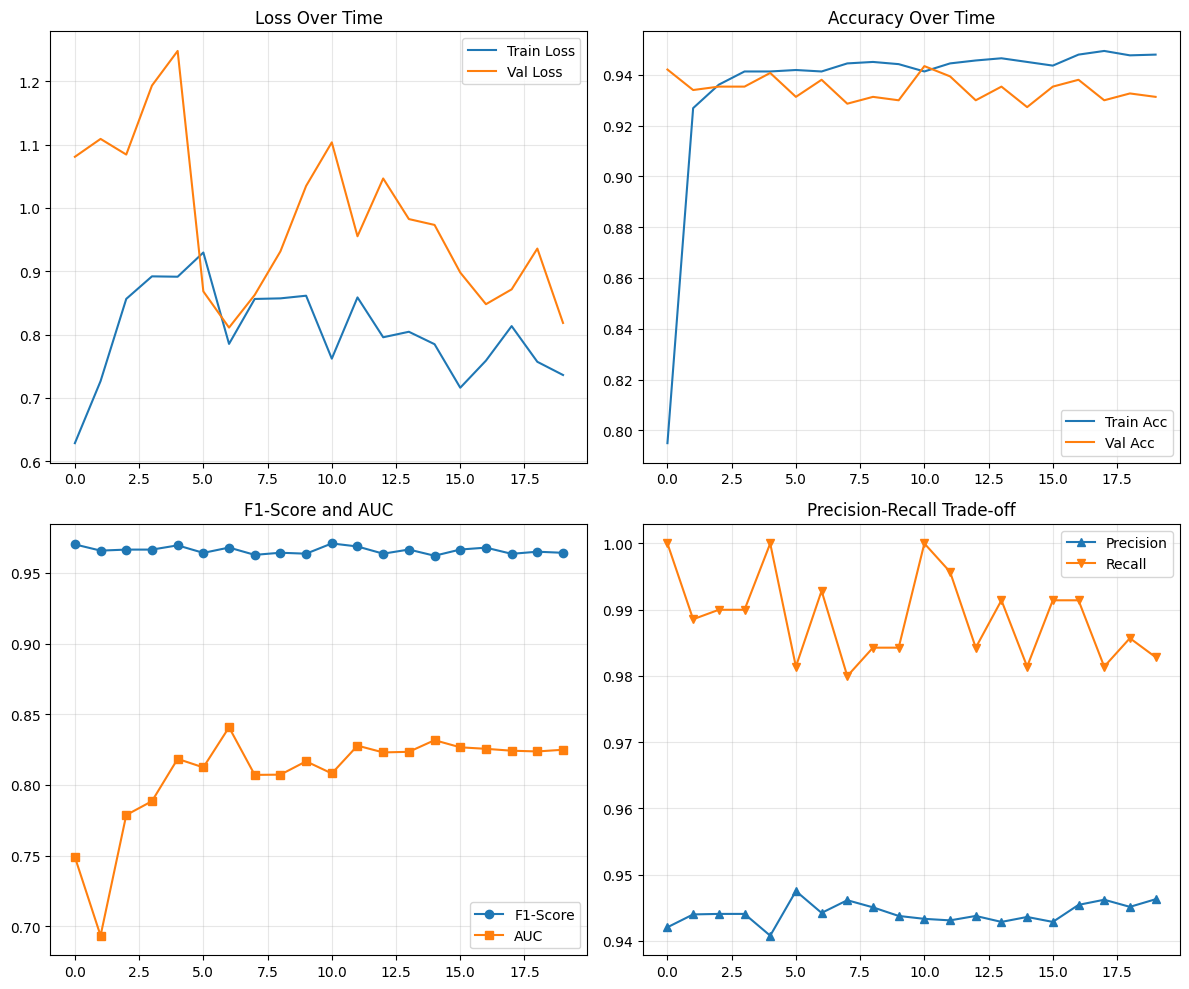

✅ Training history plot saved to ../../reports/mian/figures\mian_training_history.png


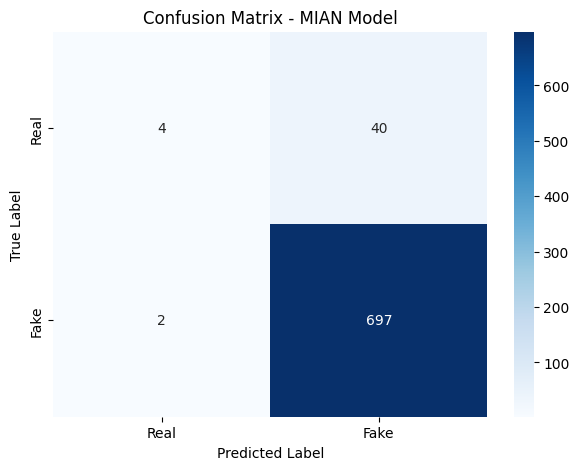

✅ Confusion matrix saved to ../../reports/mian/figures\mian_confusion_matrix.png


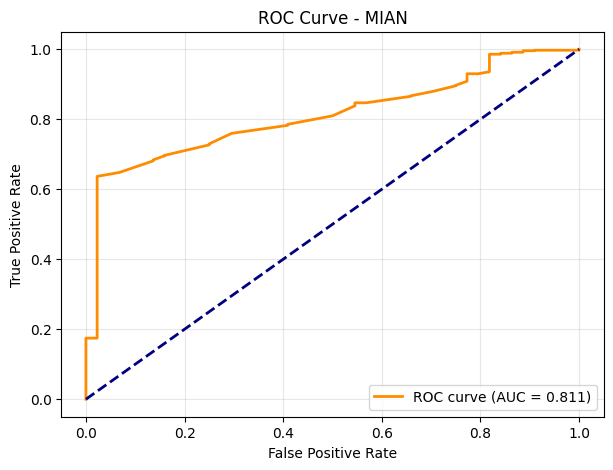

✅ ROC curve saved to ../../reports/mian/figures\mian_roc_curve.png


In [10]:
class MIANVisualizer:
    @staticmethod
    def plot_all(metrics_history, test_metrics, save_dir='../../reports/mian/figures'):
        os.makedirs(save_dir, exist_ok=True)
        
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        axes[0, 0].plot(metrics_history['train_loss'], label='Train Loss')
        axes[0, 0].plot(metrics_history['val_loss'], label='Val Loss')
        axes[0, 0].set_title('Loss Over Time')
        axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)
        
        axes[0, 1].plot(metrics_history['train_acc'], label='Train Acc')
        axes[0, 1].plot(metrics_history['val_acc'], label='Val Acc')
        axes[0, 1].set_title('Accuracy Over Time')
        axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)
        
        axes[1, 0].plot(metrics_history['f1'], label='F1-Score', marker='o')
        axes[1, 0].plot(metrics_history['auc'], label='AUC', marker='s')
        axes[1, 0].set_title('F1-Score and AUC')
        axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)
        
        axes[1, 1].plot(metrics_history['precision'], label='Precision', marker='^')
        axes[1, 1].plot(metrics_history['recall'], label='Recall', marker='v')
        axes[1, 1].set_title('Precision-Recall Trade-off')
        axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        history_path = os.path.join(save_dir, 'mian_training_history.png')
        plt.savefig(history_path, dpi=100, bbox_inches='tight')
        plt.show()
        plt.close()
        print(f"✅ Training history plot saved to {history_path}")
        
        cm = confusion_matrix(test_metrics['true_labels'], test_metrics['predictions'])
        plt.figure(figsize=(7, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
        plt.title('Confusion Matrix - MIAN Model')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        cm_path = os.path.join(save_dir, 'mian_confusion_matrix.png')
        plt.savefig(cm_path, dpi=100, bbox_inches='tight')
        plt.show()
        plt.close()
        print(f"✅ Confusion matrix saved to {cm_path}")
        
        fpr, tpr, _ = roc_curve(test_metrics['true_labels'], test_metrics['probabilities'])
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(7, 5))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.title('ROC Curve - MIAN')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)
        roc_path = os.path.join(save_dir, 'mian_roc_curve.png')
        plt.savefig(roc_path, dpi=100, bbox_inches='tight')
        plt.show()
        plt.close()
        print(f"✅ ROC curve saved to {roc_path}")

MIANVisualizer.plot_all(metrics_history, test_metrics)


**Report Generation & Registry Update**

In [11]:
class MIANModelSaver:
    @staticmethod
    def generate_report(metrics_history, test_metrics, save_name="MIAN"):
        report_dir = "../../reports/mian/metrics"
        os.makedirs(report_dir, exist_ok=True)
        report_path = os.path.join(report_dir, f"{save_name}_Report.txt")
        
        y_true = test_metrics['true_labels']
        y_pred = test_metrics['predictions']
        
        p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
        p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
        
        best_val_acc = max(metrics_history['val_acc']) if metrics_history['val_acc'] else test_metrics['accuracy']
        best_val_f1 = max(metrics_history['f1']) if metrics_history['f1'] else test_metrics['f1']
        
        report_content = f"""==================================================
{save_name} MODEL FAKE NEWS DETECTION REPORT
==================================================
Test Accuracy:         {test_metrics['accuracy']:.6f}
Test Precision (Bin):  {test_metrics['precision']:.6f}
Test Recall (Bin):     {test_metrics['recall']:.6f}
Test F1-Score (Bin):   {test_metrics['f1']:.6f}
Test F1-Score (Macro): {f1_macro:.6f}
Test F1-Score (Wtd):   {f1_weighted:.6f}
Test AUC-ROC:          {test_metrics['auc']:.6f}
Inference Time (sec):  {test_metrics['inference_time']:.2f}
==================================================
"""
        with open(report_path, "w", encoding="utf-8") as f:
            f.write(report_content)
            
        print(f"✅ Performance report saved to {report_path}")
        
        update_registry(
            name="MIAN",
            arch="MIANWithFeatures",
            rel_path="models/mian/best_mian_model.pth",
            val_accuracy=float(best_val_acc),
            val_f1=float(best_val_f1),
            test_accuracy=float(test_metrics['accuracy']),
            test_f1=float(test_metrics['f1']),
            test_auc=float(test_metrics['auc']),
            img_dim=768,
            text_dim=768,
            num_classes=2
        )

MIANModelSaver.generate_report(metrics_history, test_metrics)


✅ Performance report saved to ../../reports/mian/metrics\MIAN_Report.txt
ℹ️  Registry unchanged — current champion 'Fusion - Metadata Fusion (MLP)' (acc=0.9462) leads 'MIAN' (acc=0.9435).
